# Q2: Pix2Pix — Sketch-to-Image & Colorization
**Course:** Generative AI (AI4009) | **Assignment:** 03 | **Platform:** Kaggle T4 x2

**Group:** 22F-3845 & 22F-3360

## Cell 1 — Imports

In [1]:
import os
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms
from torchvision.utils import save_image
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

Device: cuda
  GPU 0: Tesla T4
  GPU 1: Tesla T4


## Cell 2 — Hyperparameters

In [2]:
IMG_SIZE   = 256
BATCH_SIZE = 16
LR         = 0.0002
BETAS      = (0.5, 0.999)
EPOCHS     = 30
LAMBDA_L1  = 100
SAVE_EVERY = 5

# ALL paths use /kaggle/working/ — this is the only writable folder
os.makedirs('/kaggle/working/outputs/pix2pix', exist_ok=True)
os.makedirs('/kaggle/working/checkpoints',     exist_ok=True)
print('Config ready.')
print(f'Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}')

Config ready.
Epochs: 30 | Batch: 16 | LR: 0.0002


## Cell 3 — Dataset Paths (Verified)

In [3]:
# Hardcoded paths confirmed working from earlier path check
ANIME_TRAIN = '/kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair/data/train'
ANIME_VAL   = '/kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair/data/val'

VALID = {'.png', '.jpg', '.jpeg'}
anime_count = len([f for f in os.listdir(ANIME_TRAIN) if os.path.splitext(f)[1].lower() in VALID])
print(f'Anime train images : {anime_count}')
print('Paths verified!')

Anime train images : 14224
Paths verified!


## Cell 4 — Dataset Classes

In [4]:
class AnimeSketchDataset(Dataset):
    VALID = {'.png', '.jpg', '.jpeg'}

    def __init__(self, folder, img_size=256):
        self.paths = []
        for root, _, files in os.walk(folder):
            for f in files:
                if os.path.splitext(f)[1].lower() in self.VALID:
                    self.paths.append(os.path.join(root, f))
        self.t = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])
        print(f'AnimeSketchDataset: {len(self.paths)} images found')

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img    = Image.open(self.paths[idx]).convert('RGB')
        w, h   = img.size
        color  = img.crop((0,    0, w//2, h))
        sketch = img.crop((w//2, 0, w,    h))
        return self.t(sketch), self.t(color)


class CUHKDataset(Dataset):
    VALID = {'.png', '.jpg', '.jpeg'}

    def __init__(self, sketch_dir, photo_dir, img_size=256):
        get = lambda d: sorted([
            os.path.join(d, f) for f in os.listdir(d)
            if os.path.splitext(f)[1].lower() in self.VALID
        ])
        self.sketches = get(sketch_dir)
        self.photos   = get(photo_dir)
        n = min(len(self.sketches), len(self.photos))
        self.sketches = self.sketches[:n]
        self.photos   = self.photos[:n]
        self.t = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])
        print(f'CUHKDataset: {n} pairs')

    def __len__(self): return len(self.sketches)

    def __getitem__(self, idx):
        sketch = Image.open(self.sketches[idx]).convert('RGB')
        photo  = Image.open(self.photos[idx]).convert('RGB')
        return self.t(sketch), self.t(photo)


# Build dataset
anime_dataset = AnimeSketchDataset(ANIME_TRAIN, IMG_SIZE)
full_dataset  = anime_dataset

# Use subset for faster training
SUBSET_SIZE    = min(len(full_dataset), 5000)
subset_indices = torch.randperm(len(full_dataset))[:SUBSET_SIZE]
dataset        = torch.utils.data.Subset(full_dataset, subset_indices)

dataloader = DataLoader(
    dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2,
    pin_memory=True, drop_last=True
)
print(f'Total dataset  : {len(full_dataset)}')
print(f'Using subset   : {SUBSET_SIZE}')
print(f'Batches/epoch  : {len(dataloader)}')

AnimeSketchDataset: 14224 images found
Total dataset  : 14224
Using subset   : 5000
Batches/epoch  : 312


## Cell 5 — Visualise Dataset Pairs

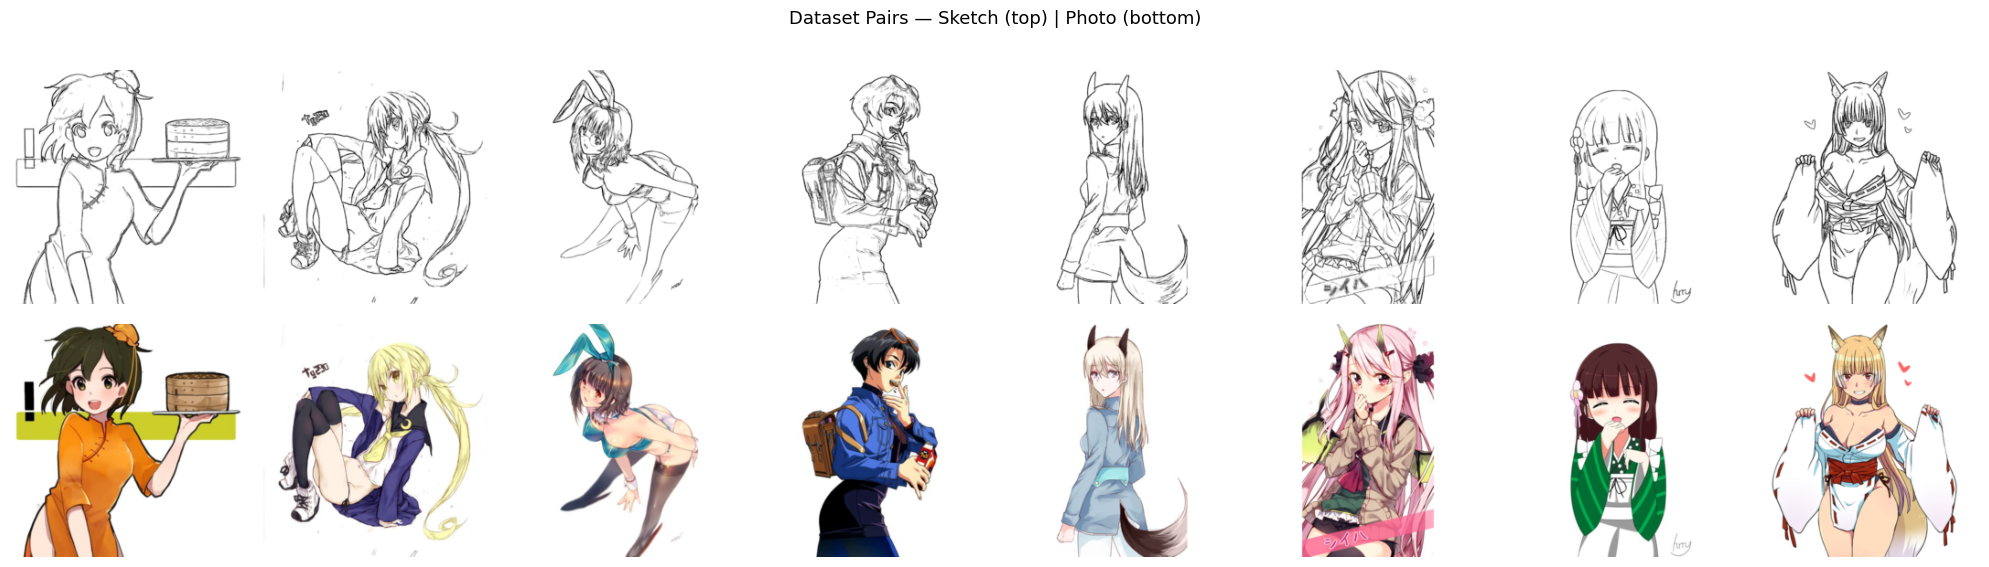

Sample pairs shown — sketch on top, color on bottom.


In [5]:
sketches, photos = next(iter(dataloader))
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle('Dataset Pairs — Sketch (top) | Photo (bottom)', fontsize=13)
for i in range(8):
    for row, imgs in enumerate([sketches, photos]):
        img = imgs[i].permute(1,2,0).numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        axes[row,i].imshow(img)
        axes[row,i].axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/outputs/pix2pix/dataset_pairs.png', dpi=100)
plt.show()
print('Sample pairs shown — sketch on top, color on bottom.')

## Cell 6 — U-Net Generator

In [6]:
class UNetBlock(nn.Module):
    """Single encoder or decoder block for U-Net."""
    def __init__(self, in_ch, out_ch, down=True, use_bn=True, dropout=False):
        super().__init__()
        if down:
            self.conv = nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=not use_bn)
        else:
            self.conv = nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=not use_bn)
        self.bn      = nn.BatchNorm2d(out_ch) if use_bn else nn.Identity()
        self.act     = nn.LeakyReLU(0.2) if down else nn.ReLU()
        self.dropout = nn.Dropout(0.5) if dropout else nn.Identity()

    def forward(self, x):
        return self.dropout(self.bn(self.act(self.conv(x))))


class UNetGenerator(nn.Module):
    """
    U-Net Generator for Pix2Pix.
    Input:  (B, 3, 256, 256) sketch
    Output: (B, 3, 256, 256) realistic image
    Uses skip connections to preserve spatial details.
    """
    def __init__(self, in_ch=3, out_ch=3, f=64):
        super().__init__()
        # Encoder (downsampling)
        self.e1 = nn.Sequential(nn.Conv2d(in_ch, f, 4,2,1), nn.LeakyReLU(0.2))  # 128
        self.e2 = UNetBlock(f,   f*2, down=True)           # 64
        self.e3 = UNetBlock(f*2, f*4, down=True)           # 32
        self.e4 = UNetBlock(f*4, f*8, down=True)           # 16
        self.e5 = UNetBlock(f*8, f*8, down=True)           # 8
        self.e6 = UNetBlock(f*8, f*8, down=True)           # 4
        self.e7 = UNetBlock(f*8, f*8, down=True)           # 2
        self.e8 = UNetBlock(f*8, f*8, down=True, use_bn=False)  # 1 bottleneck

        # Decoder (upsampling with skip connections — input channels doubled)
        self.d1 = UNetBlock(f*8,   f*8, down=False, dropout=True)   # 2
        self.d2 = UNetBlock(f*16,  f*8, down=False, dropout=True)   # 4
        self.d3 = UNetBlock(f*16,  f*8, down=False, dropout=True)   # 8
        self.d4 = UNetBlock(f*16,  f*8, down=False)                 # 16
        self.d5 = UNetBlock(f*16,  f*4, down=False)                 # 32
        self.d6 = UNetBlock(f*8,   f*2, down=False)                 # 64
        self.d7 = UNetBlock(f*4,   f,   down=False)                 # 128
        self.d8 = nn.Sequential(
            nn.ConvTranspose2d(f*2, out_ch, 4, 2, 1),
            nn.Tanh()
        )                                                            # 256

    def forward(self, x):
        e1 = self.e1(x);  e2 = self.e2(e1); e3 = self.e3(e2); e4 = self.e4(e3)
        e5 = self.e5(e4); e6 = self.e6(e5); e7 = self.e7(e6); e8 = self.e8(e7)
        d1 = self.d1(e8)
        d2 = self.d2(torch.cat([d1, e7], 1))
        d3 = self.d3(torch.cat([d2, e6], 1))
        d4 = self.d4(torch.cat([d3, e5], 1))
        d5 = self.d5(torch.cat([d4, e4], 1))
        d6 = self.d6(torch.cat([d5, e3], 1))
        d7 = self.d7(torch.cat([d6, e2], 1))
        return self.d8(torch.cat([d7, e1], 1))

# Quick shape test
_g = UNetGenerator().to(device)
_x = torch.randn(1, 3, 256, 256).to(device)
print(f'Generator output shape: {_g(_x).shape}')  # should be (1, 3, 256, 256)
del _g, _x
print('U-Net Generator defined!')

Generator output shape: torch.Size([1, 3, 256, 256])
U-Net Generator defined!


## Cell 7 — PatchGAN Discriminator

In [7]:
class PatchGANDiscriminator(nn.Module):
    """
    PatchGAN: classifies 30x30 patches of the image.
    Input: concat(sketch, real_or_fake) → (B, 6, 256, 256)
    Output: (B, 1, 30, 30) — NO Sigmoid (BCEWithLogitsLoss handles it)
    """
    def __init__(self, in_ch=6, f=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, f,   4, 2, 1, bias=False), nn.LeakyReLU(0.2, True),
            nn.Conv2d(f,   f*2, 4, 2, 1, bias=False), nn.BatchNorm2d(f*2), nn.LeakyReLU(0.2, True),
            nn.Conv2d(f*2, f*4, 4, 2, 1, bias=False), nn.BatchNorm2d(f*4), nn.LeakyReLU(0.2, True),
            nn.Conv2d(f*4, f*8, 4, 1, 1, bias=False), nn.BatchNorm2d(f*8), nn.LeakyReLU(0.2, True),
            nn.Conv2d(f*8, 1,   4, 1, 1, bias=False)
        )

    def forward(self, sketch, target):
        return self.net(torch.cat([sketch, target], dim=1))


def weights_init(m):
    cls = m.__class__.__name__
    if 'Conv' in cls:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in cls:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


G = UNetGenerator().to(device)
D = PatchGANDiscriminator().to(device)

if torch.cuda.device_count() > 1:
    G = nn.DataParallel(G)
    D = nn.DataParallel(D)
    print(f'DataParallel on {torch.cuda.device_count()} GPUs')

G.apply(weights_init)
D.apply(weights_init)
print(f'Generator     params: {sum(p.numel() for p in G.parameters()):,}')
print(f'Discriminator params: {sum(p.numel() for p in D.parameters()):,}')
print('Pix2Pix models initialised!')

DataParallel on 2 GPUs
Generator     params: 54,414,531
Discriminator params: 2,768,640
Pix2Pix models initialised!


## Cell 8 — Train Pix2Pix

In [ ]:
opt_G    = optim.Adam(G.parameters(), lr=LR, betas=BETAS)
opt_D    = optim.Adam(D.parameters(), lr=LR, betas=BETAS)
adv_loss = nn.BCEWithLogitsLoss()
l1_loss  = nn.L1Loss()
scaler   = torch.amp.GradScaler('cuda')

G_losses, D_losses = [], []

# Fixed batch for consistent visualization every epoch
fixed_sketches, fixed_photos = next(iter(dataloader))
fixed_sketches = fixed_sketches[:4].to(device)
fixed_photos   = fixed_photos[:4].to(device)

print('Starting Pix2Pix Training...')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):
    ep_G, ep_D = 0.0, 0.0
    loop = tqdm(dataloader, desc=f'[Pix2Pix] Epoch {epoch}/{EPOCHS}', leave=False)

    for sketch, real in loop:
        sketch = sketch.to(device)
        real   = real.to(device)

        # ── Train Discriminator ──────────────────────────
        opt_D.zero_grad()
        with torch.amp.autocast('cuda'):
            fake      = G(sketch).detach()
            pred_real = D(sketch, real)
            pred_fake = D(sketch, fake)
            loss_D    = (adv_loss(pred_real, torch.ones_like(pred_real)) +
                         adv_loss(pred_fake, torch.zeros_like(pred_fake))) * 0.5
        scaler.scale(loss_D).backward()
        scaler.step(opt_D)

        # ── Train Generator ──────────────────────────────
        opt_G.zero_grad()
        with torch.amp.autocast('cuda'):
            fake      = G(sketch)
            pred_fake = D(sketch, fake)
            loss_GAN  = adv_loss(pred_fake, torch.ones_like(pred_fake))
            loss_L1   = l1_loss(fake, real) * LAMBDA_L1
            loss_G    = loss_GAN + loss_L1
        scaler.scale(loss_G).backward()
        scaler.step(opt_G)
        scaler.update()

        ep_G += loss_G.item()
        ep_D += loss_D.item()
        loop.set_postfix(G=f'{loss_G.item():.3f}', D=f'{loss_D.item():.3f}')

    avg_G = ep_G / len(dataloader)
    avg_D = ep_D / len(dataloader)
    G_losses.append(avg_G)
    D_losses.append(avg_D)
    print(f'[Pix2Pix] Epoch {epoch:03d}/{EPOCHS} | G: {avg_G:.4f} | D: {avg_D:.4f}')

    # Save sample outputs every epoch
    G.eval()
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            fake_vis = G(fixed_sketches).cpu()
    G.train()
    combo = torch.cat([fixed_sketches.cpu(), fake_vis, fixed_photos.cpu()], dim=0)
    save_image(combo,
               f'/kaggle/working/outputs/pix2pix/epoch_{epoch:03d}.png',
               normalize=True, value_range=(-1,1), nrow=4)

    # Save checkpoint every SAVE_EVERY epochs — uses /kaggle/working/ path
    if epoch % SAVE_EVERY == 0:
        ckpt_path = f'/kaggle/working/checkpoints/pix2pix_{epoch:03d}.pth'
        torch.save({
            'epoch':  epoch,
            'G':      G.state_dict(),
            'D':      D.state_dict(),
            'G_loss': G_losses,
            'D_loss': D_losses
        }, ckpt_path)
        print(f'  Checkpoint saved: {ckpt_path}')

print('Pix2Pix Training Complete!')

Starting Pix2Pix Training...


[Pix2Pix] Epoch 001/30 | G: 29.9094 | D: 0.4188


[Pix2Pix] Epoch 002/30 | G: 22.2679 | D: 0.4710


[Pix2Pix] Epoch 003/30 | G: 20.5046 | D: 0.5197


[Pix2Pix] Epoch 004/30 | G: 19.6624 | D: 0.5371


[Pix2Pix] Epoch 005/30 | G: 19.1696 | D: 0.5024
  Checkpoint saved: /kaggle/working/checkpoints/pix2pix_005.pth


[Pix2Pix] Epoch 006/30 | G: 18.5784 | D: 0.4997


[Pix2Pix] Epoch 7/30:  79%|███████▉  | 247/312 [01:23<00:21,  2.96it/s, D=0.360, G=18.091]

In [11]:
# Save final model weights + loss history so training doesn't need to repeat
SAVE_DIR = '/kaggle/working/outputs/pix2pix'
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save({
    'G_state_dict': G.state_dict(),
    'D_state_dict': D.state_dict(),
    'G_losses':     G_losses,
    'D_losses':     D_losses,
    'epoch':        EPOCHS,
}, f'{SAVE_DIR}/pix2pix_final.pth')

print(f'Saved to {SAVE_DIR}/pix2pix_final.pth')
print(f'File size: {os.path.getsize(f"{SAVE_DIR}/pix2pix_final.pth") / 1e6:.1f} MB')

Saved to /kaggle/working/outputs/pix2pix/pix2pix_final.pth
File size: 228.8 MB


In [12]:
checkpoint = torch.load('/kaggle/working/outputs/pix2pix/pix2pix_final.pth', map_location=device)
G.load_state_dict(checkpoint['G_state_dict'])
D.load_state_dict(checkpoint['D_state_dict'])
G_losses = checkpoint['G_losses']
D_losses = checkpoint['D_losses']
G.eval()
print(f'Loaded checkpoint from epoch {checkpoint["epoch"]}')

Loaded checkpoint from epoch 30


## Cell 9 — Loss Plots

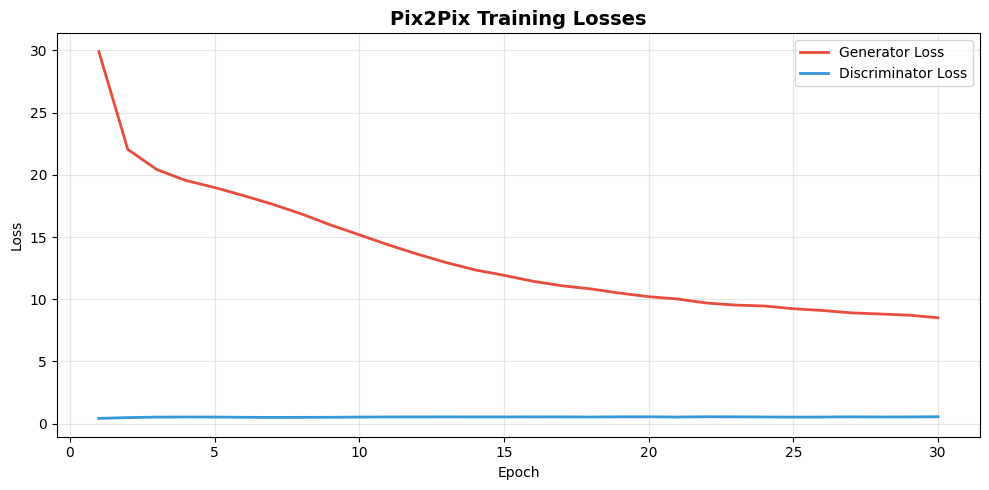

Loss plot saved!


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ep = range(1, len(G_losses)+1)
ax.plot(ep, G_losses, label='Generator Loss',     color='#e74c3c', lw=2)
ax.plot(ep, D_losses, label='Discriminator Loss', color='#3498db', lw=2)
ax.set_title('Pix2Pix Training Losses', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/outputs/pix2pix/training_losses.png', dpi=150)
plt.show()
print('Loss plot saved!')

## Cell 10 — Qualitative Results (Input | Output | Ground Truth)

In [1]:
def show_pix2pix_results(generator, dataloader, n=8):
    generator.eval()
    sketches, reals = next(iter(dataloader))
    sketches = sketches[:n].to(device)
    reals    = reals[:n]

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            fakes = generator(sketches).cpu()
    sketches = sketches.cpu()

    fig, axes = plt.subplots(3, n, figsize=(n*2.5, 9))
    row_labels = ['Input Sketch', 'Generated Output', 'Ground Truth']

    for col in range(n):
        for row, imgs in enumerate([sketches, fakes, reals]):
            img = imgs[col].permute(1,2,0).numpy().astype(np.float32)  # fix here
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
            axes[row, col].imshow(img)
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(row_labels[row], fontsize=10, fontweight='bold')

    fig.suptitle('Pix2Pix Results: Sketch → Image', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/outputs/pix2pix/qualitative_results.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    generator.train()

show_pix2pix_results(G, dataloader)

NameError: name 'G' is not defined

## Cell 11 — SSIM & PSNR Evaluation

In [19]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'scikit-image'])
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

def evaluate_metrics(generator, dataloader, n_batches=5):
    generator.eval()
    ssim_scores, psnr_scores = [], []

    with torch.no_grad():
        for i, (sketch, real) in enumerate(dataloader):
            if i >= n_batches:
                break
            sketch = sketch.to(device)
            with torch.amp.autocast('cuda'):
                fake = generator(sketch).cpu()
            real = real.cpu()

            for j in range(fake.size(0)):
                f = ((fake[j].permute(1,2,0).numpy() + 1) / 2 * 255).astype(np.uint8)
                r = ((real[j].permute(1,2,0).numpy() + 1) / 2 * 255).astype(np.uint8)
                ssim_scores.append(ssim_fn(r, f, channel_axis=2, data_range=255))
                psnr_scores.append(psnr_fn(r, f, data_range=255))

    generator.train()
    return np.mean(ssim_scores), np.mean(psnr_scores)

ssim_val, psnr_val = evaluate_metrics(G, dataloader)
print(f'SSIM : {ssim_val:.4f}  (higher is better, max=1.0)')
print(f'PSNR : {psnr_val:.2f} dB  (higher is better)')

SSIM : 0.7279  (higher is better, max=1.0)
PSNR : 19.55 dB  (higher is better)


## Cell 12 — Save Final Weights

In [20]:
# Save generator and discriminator weights
torch.save(G.state_dict(),
           '/kaggle/working/outputs/pix2pix_generator_final.pth')
torch.save(D.state_dict(),
           '/kaggle/working/outputs/pix2pix_discriminator_final.pth')

# Save loss history and metrics
with open('/kaggle/working/outputs/pix2pix_loss_history.pkl', 'wb') as f:
    pickle.dump({
        'G':    G_losses,
        'D':    D_losses,
        'ssim': ssim_val,
        'psnr': psnr_val
    }, f)

print('All files saved to /kaggle/working/outputs/:')
for f in sorted(os.listdir('/kaggle/working/outputs')):
    fpath = f'/kaggle/working/outputs/{f}'
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / 1024
        print(f'  {f}  ({size:.1f} KB)')
    else:
        print(f'  {f}/')

All files saved to /kaggle/working/outputs/:
  pix2pix/
  pix2pix_discriminator_final.pth  (10829.9 KB)
  pix2pix_generator_final.pth  (212625.5 KB)
  pix2pix_loss_history.pkl  (0.7 KB)
